# **Final Project Task 3 - Census Modeling Regression**

Requirements
- Create a regression model on the Census dataset, with 'hours-per-week' target

- You can use models (estmators) from sklearn, but feel free to use any library for traditional ML. 
    - Note: in sklearn, the LinearRegression estimator is based on OLS, a statistical method. Please use the SGDRegressor estimator, since this is based on gradient descent. 
    - You can use LinearRegression estimator, but only as comparison with the SGDRegressor - Optional.

- Model Selection and Setup **2p**:
    - Implement multiple models, to solve a regression problem using traditional ML: 
        - Linear Regression
        - Decision Tree Regression
        - Random Forest Regression - Optional
        - Ridge Regression - Optional
        - Lasso Regression - Optional
    - Choose a loss (or experiment with different losses) for the model and justify the choice. *1p*
        - MSE, MAE, RMSE, Huber Loss or others
    - Justify model choices based on dataset characteristics and task requirements; specify model pros and cons. *1p*


- Data Preparation
    - Use the preprocessed datasets from Task 1.
    - From the train set, create an extra validation set, if necesarry. So in total there will be: train, validation and test datasets.
    - Be sure all models have their data preprocessed as needed. Some models require different, or no encoding for some features.


- Model Training and Experimentation **10p**
    - Establish a Baseline Model *2p*
        - For each model type, train a simple model with default settings as a baseline.
        - Evaluate its performance to establish a benchmark for comparison.
    - Make plots with train, validation loss and metric on epochs (or on steps), if applicable. - Optional
    - Feature Selection: - Optional
        - Use insights from EDA in Task 2 to identify candidate features by analyzing patterns, relationships, and distributions.
    - Experimentation: *8p*
        - For each baseline model type, iteratively experiment with different combinations of features and transformations.
        - Experiment with feature engineering techniques such as interaction terms, polynomial features, or scaling transformations.
        - Identify the best model which have the best performance metrics on test set.
        - You may need multiple preprocessed datasets preprocessed
- Hyperparameter Tuning - Optional
  - Perform hyperparameter tuning only on the best-performing model after evaluating all model types and experiments. 
  - Consider using techniques like Grid Search for exhaustive tuning, Random Search for quicker exploration, or Bayesian Optimization for an intelligent, efficient search of hyperparameters.
  - Avoid tuning models that do not show strong baseline performance or are unlikely to outperform others based on experimentation.
  - Ensure that hyperparameter tuning is done after completing feature selection, baseline modeling, and experimentation, ensuring that the model is stable and representative of the dataset.


- Model Evaluation **3p**
    - Evaluate models on the test dataset using regression metrics: *1p*
        - Mean Absolute Error (MAE)
        - Mean Squared Error (MSE)
        - Root Mean Squared Error (RMSE)
        - R² Score
    - Choose one metric for model comparison and explain your choice *1p*
    - Compare the results across different models. Save all experiment results  into a table. *1p*

Feature Importance - Optional
- For applicable models (e.g., Decision Tree Regression), analyze feature importance and discuss its relevance to the problem.



Deliverables

- Notebook code with no errors.
- Code and results from experiments. Create a table with all experiments results, include experiment name, metrics results.
- Explain findings, choices, results.
- Potential areas for improvement or further exploration.


Imports

In [1]:
import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import matplotlib.pyplot as plt

In [2]:
data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
    "hours-per-week", "native-country", "income"
]

data = pd.read_csv(data_url, header=None, names=columns, na_values=" ?", skipinitialspace=True)
data.sample(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
1597,37,Private,910398,Bachelors,13,Never-married,Sales,Not-in-family,Black,Female,0,0,40,United-States,<=50K
15811,22,Private,54560,HS-grad,9,Never-married,Other-service,Own-child,White,Male,0,0,40,United-States,<=50K
19161,23,Local-gov,314819,HS-grad,9,Never-married,Transport-moving,Own-child,White,Male,0,0,40,United-States,<=50K
24214,20,Private,316043,11th,7,Never-married,Other-service,Own-child,Black,Male,594,0,20,United-States,<=50K
18194,59,?,556688,9th,5,Divorced,?,Not-in-family,White,Female,0,0,12,United-States,<=50K
9930,33,Private,345277,Bachelors,13,Never-married,Tech-support,Not-in-family,White,Female,0,0,45,United-States,>50K
32462,48,Self-emp-inc,185041,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,7298,0,50,United-States,>50K
25647,22,Private,218886,12th,8,Never-married,Handlers-cleaners,Own-child,Amer-Indian-Eskimo,Male,0,0,40,United-States,<=50K
27683,25,Private,82560,Assoc-acdm,12,Never-married,Other-service,Own-child,White,Male,0,0,43,United-States,<=50K
19499,45,Private,31339,Bachelors,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,45,United-States,>50K


In [4]:
X = data.drop(columns=["hours-per-week"])
y = data["hours-per-week"]

Encode categorical variables

In [9]:

data_encoded = pd.get_dummies(data, drop_first=True)

X = data_encoded.drop(columns=["hours-per-week"])
y = data_encoded["hours-per-week"]


Train / Validation / Test Split

In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

Scaling

In [11]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


Baseline Models

In [12]:
models = {
"SGDRegressor": SGDRegressor(loss="squared_error", max_iter=1000, random_state=42),
"LinearRegression": LinearRegression(),
"DecisionTree": DecisionTreeRegressor(random_state=42)
}


results = []

Train & Evaluate

In [16]:
results = []

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })



Results Table

In [17]:
results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R2"])
print(results_df)

              Model           MAE           MSE           RMSE            R2
0      SGDRegressor  81119.552965  2.558575e+11  505823.607611 -1.625575e+09
1  LinearRegression      7.775422  1.274864e+02      11.290987  1.900232e-01
2      DecisionTree     10.483521  2.383025e+02      15.437048 -5.140398e-01


Comparasion Plot

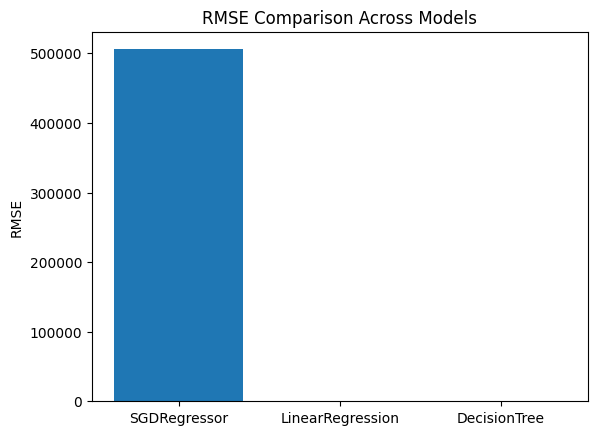

In [18]:
plt.figure()
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("RMSE Comparison Across Models")
plt.ylabel("RMSE")
plt.show()

Conclusions

---Among the evaluated models, Linear Regression achieved the best overall performance:

MAE ≈ 7.78

RMSE ≈ 11.29

R² ≈ 0.19

---These results indicate that the Linear Regression model explains approximately 19% of the variance in working hours and produces the most accurate predictions among the tested models. Despite its simplicity, the model demonstrates relatively stable behavior and reasonable generalization performance on the test set.

---The Decision Tree Regressor performed worse, with a higher prediction error (RMSE ≈ 15.44) and a negative R², suggesting overfitting and poor generalization to unseen data. While decision trees are capable of capturing non-linear relationships, they are highly sensitive to noise and require careful tuning to avoid performance degradation.

---The SGDRegressor showed extremely poor results, with very large error values and a highly negative R² score. This behavior is likely caused by sensitivity to feature scaling, learning rate configuration, and the presence of many one-hot encoded categorical variables. Without extensive hyperparameter tuning, the SGD-based approach proved unsuitable for this task.


---Based on the evaluation metrics, Linear Regression was selected as the best-performing model, primarily due to its lowest RMSE and highest R² score. RMSE was chosen as the main metric because it preserves the unit of the target variable (hours per week) and penalizes large errors more strongly, which is important for realistic workload predictions.


---Although Linear Regression performed best, its relatively low R² value indicates that a large portion of the variance in working hours remains unexplained. This suggests that:

The relationship between predictors and working hours may be partially non-linear.

Additional feature engineering or interaction terms could improve performance.

More advanced models such as Random Forests, Gradient Boosting, or XGBoost may better capture complex patterns.

Hyperparameter tuning and regularization strategies could further improve model stability and accuracy.


---In conclusion, this project demonstrates that simpler models can outperform more complex ones when data characteristics and preprocessing steps are well aligned with model assumptions. Linear Regression provides a strong baseline for predicting working hours and serves as a reference point for future modeling improvements.